In [5]:
import numpy as np
import pandas as pd
import os

In [2]:
path = "/projects/standard/kumarv/renga/Public/DATA/camels_us_531/PREPROCESSED" # RAW OR PREPROCESSED
raw_data_path = "/projects/standard/kumarv/renga/Public/DATA/camels_us_531/RAW"

In [7]:
ls /projects/standard/kumarv/renga/Public/DATA/camels_us_531/PREPROCESSED/

embeddings/               strided_train.npz          test_inverse.npz
feature_names.npy         strided_train_inverse.npz  train.npz
models/                   strided_valid.npz          train_inverse.npz
strided_test.npz          strided_valid_inverse.npz  valid.npz
strided_test_inverse.npz  test.npz                   valid_inverse.npz


In [5]:
data = np.load(f"{path}/strided_train.npz")

In [6]:
data['data'].shape

(531, 19, 365, 33)

In [7]:
dates = np.load(f"{raw_data_path}/dates.npy", allow_pickle=True)
feature_names = np.load(f"{raw_data_path}/feature_names.npy", allow_pickle=True)

print(feature_names)

['p_mean' 'pet_mean' 'p_seasonality' 'frac_snow' 'aridity'
 'high_prec_freq' 'high_prec_dur' 'low_prec_freq' 'low_prec_dur'
 'carbonate_rocks_frac' 'geol_permeability' 'soil_depth_pelletier'
 'soil_depth_statsgo' 'soil_porosity' 'soil_conductivity'
 'max_water_content' 'sand_frac' 'silt_frac' 'clay_frac' 'elev_mean'
 'slope_mean' 'area_gages2' 'frac_forest' 'lai_max' 'lai_diff' 'gvf_max'
 'gvf_diff' 'PRCP(mm/day)' 'SRAD(W/m2)' 'Tmax(C)' 'Tmin(C)' 'Vp(Pa)' 'SF']


In [8]:
basin_list = np.load(f"{raw_data_path}/Basin_List.npy", allow_pickle=True)
lat_long = np.load(f"{raw_data_path}/latlong.npy", allow_pickle=True)

print(len(basin_list))
print(len(lat_long))

531
531


In [9]:
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler

In [10]:
SEED = 42 

np.random.seed(SEED)

In [11]:
N_CLUSTERS = 10   # randomly guessing 10.
N_KNOWN    = 200  # total known sites (seed + eval)
N_SEED     =  100
N_EVAL     =  100

scaler  = StandardScaler()
lat_long_scaled = scaler.fit_transform(lat_long)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=20)
cluster_labels = kmeans.fit_predict(lat_long_scaled)

In [12]:
raw_data = np.load(f"{raw_data_path}/data.npy", allow_pickle=True)
print(raw_data.shape)
static_features = raw_data[:, :, :27]

(531, 12784, 33)


In [13]:
feature_variance = static_features.var(axis=1)  
print(feature_variance.mean(axis=0))

static_features = static_features.mean(axis=1)
print(static_features.shape)

[1.2014853e-07 7.0343773e-08 1.8707165e-09 6.1911187e-10 8.6877101e-09
 3.6062611e-06 1.6291750e-08 6.0220587e-04 3.1451756e-07 6.2925920e-10
 1.6037141e-06 2.6361799e-06 6.7741208e-09 1.5219815e-09 4.0569958e-08
 2.6472475e-09 1.2914617e-05 1.1568894e-05 4.2906736e-06 1.0834795e-02
 4.5974197e-05 4.3762494e-03 4.3107100e-09 1.3408537e-07 7.6417273e-08
 4.0767483e-09 1.2999776e-09]
(531, 27)


In [14]:
def stratified_split(feature_matrix, basin_ids, n_known=100, n_clusters=10, seed=42):
    """
    Cluster basins by feature_matrix, draw n_known proportionally across
    clusters, then split them 50/50 into seed and eval sets.

    Parameters
    ----------
    feature_matrix : ndarray [n_basins, n_features]
        Already-standardised or raw features (standardised internally).
    basin_ids : ndarray [n_basins]
        Integer basin identifiers.
    n_known : int
        Total known sites (seed + eval).
    n_clusters : int
        Number of K-Means clusters / strata.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    seed_idx, eval_idx, pool_idx : ndarray
        Disjoint index arrays into basin_ids.
    cluster_labels : ndarray [n_basins]
        Cluster assignment for every basin.
    """
    np.random.seed(seed)
    n_basins = len(basin_ids)

    # Standardise
    scaler = StandardScaler()
    X = scaler.fit_transform(feature_matrix)

    # Cluster
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=20)
    cluster_labels = km.fit_predict(X)

    # Proportional allocation across clusters
    cluster_sizes = np.bincount(cluster_labels, minlength=n_clusters)
    alloc = np.maximum(1, np.round(cluster_sizes / n_basins * n_known).astype(int))
    # Fix rounding drift
    alloc[np.argmax(alloc)] += n_known - alloc.sum()

    known, seed_idx, eval_idx = [], [], []

    for c in range(n_clusters):
        members = basin_ids[cluster_labels == c]
        n_draw  = min(alloc[c], len(members))
        chosen  = np.random.choice(members, size=n_draw, replace=False)
        known.extend(chosen.tolist())

        # 50/50 seed/eval within this cluster's draw
        np.random.shuffle(chosen)
        half = len(chosen) // 2
        seed_idx.extend(chosen[:half].tolist())
        eval_idx.extend(chosen[half:].tolist())

    known    = np.array(known)
    seed_idx = np.array(seed_idx)
    eval_idx = np.array(eval_idx)
    pool_idx = basin_ids[~np.isin(basin_ids, known)]

    return seed_idx, eval_idx, pool_idx, cluster_labels

In [15]:
geo_seed, geo_eval, geo_pool, geo_clusters = stratified_split(
    lat_long, np.arange(531),
    n_known=N_KNOWN, n_clusters=N_CLUSTERS, seed=SEED
)

# print(geo_seed, geo_eval, geo_pool, geo_clusters)

hyd_seed, hyd_eval, hyd_pool, hyd_clusters = stratified_split(
    static_features, np.arange(531),
    n_known=N_KNOWN, n_clusters=N_CLUSTERS, seed=SEED
)

for name, s, e, p in [("geographic", geo_seed, geo_eval, geo_pool), ("hydrologic", hyd_seed, hyd_eval, hyd_pool)]:
    print(f"\n{name.upper()} SPLIT")
    print(f"  Seed : {len(s)}")
    print(f"  Eval : {len(e)}")
    print(f"  Pool : {len(p)}")
    print(f"  Total: {len(s)+len(e)+len(p)}")


GEOGRAPHIC SPLIT
  Seed : 97
  Eval : 103
  Pool : 331
  Total: 531

HYDROLOGIC SPLIT
  Seed : 98
  Eval : 102
  Pool : 331
  Total: 531


In [16]:
import pandas as pd

for prefix, seed, eval_, pool in [("geo", geo_seed, geo_eval, geo_pool),("hyd", hyd_seed, hyd_eval, hyd_pool)]:
    pos_to_id = {i: bid for i, bid in enumerate(basin_list)}
    
    rows = (
        [(pos_to_id[p], "seed") for p in seed] +
        [(pos_to_id[p], "eval") for p in eval_] +
        [(pos_to_id[p], "sample") for p in pool]
    )
    
    df = pd.DataFrame(rows, columns=["gauge_id", "split"])
    df = df.sort_values("gauge_id").reset_index(drop=True)
    df.to_csv(f"camels_split_{prefix}_{N_SEED}_{N_EVAL}.csv", index=False)
    print(f"Saved camels_split_{prefix}_{N_SEED}_{N_EVAL}.csv  ({len(df)} rows)")

Saved camels_split_geo_100_100.csv  (531 rows)
Saved camels_split_hyd_100_100.csv  (531 rows)


In [17]:
import matplotlib.pyplot as plt

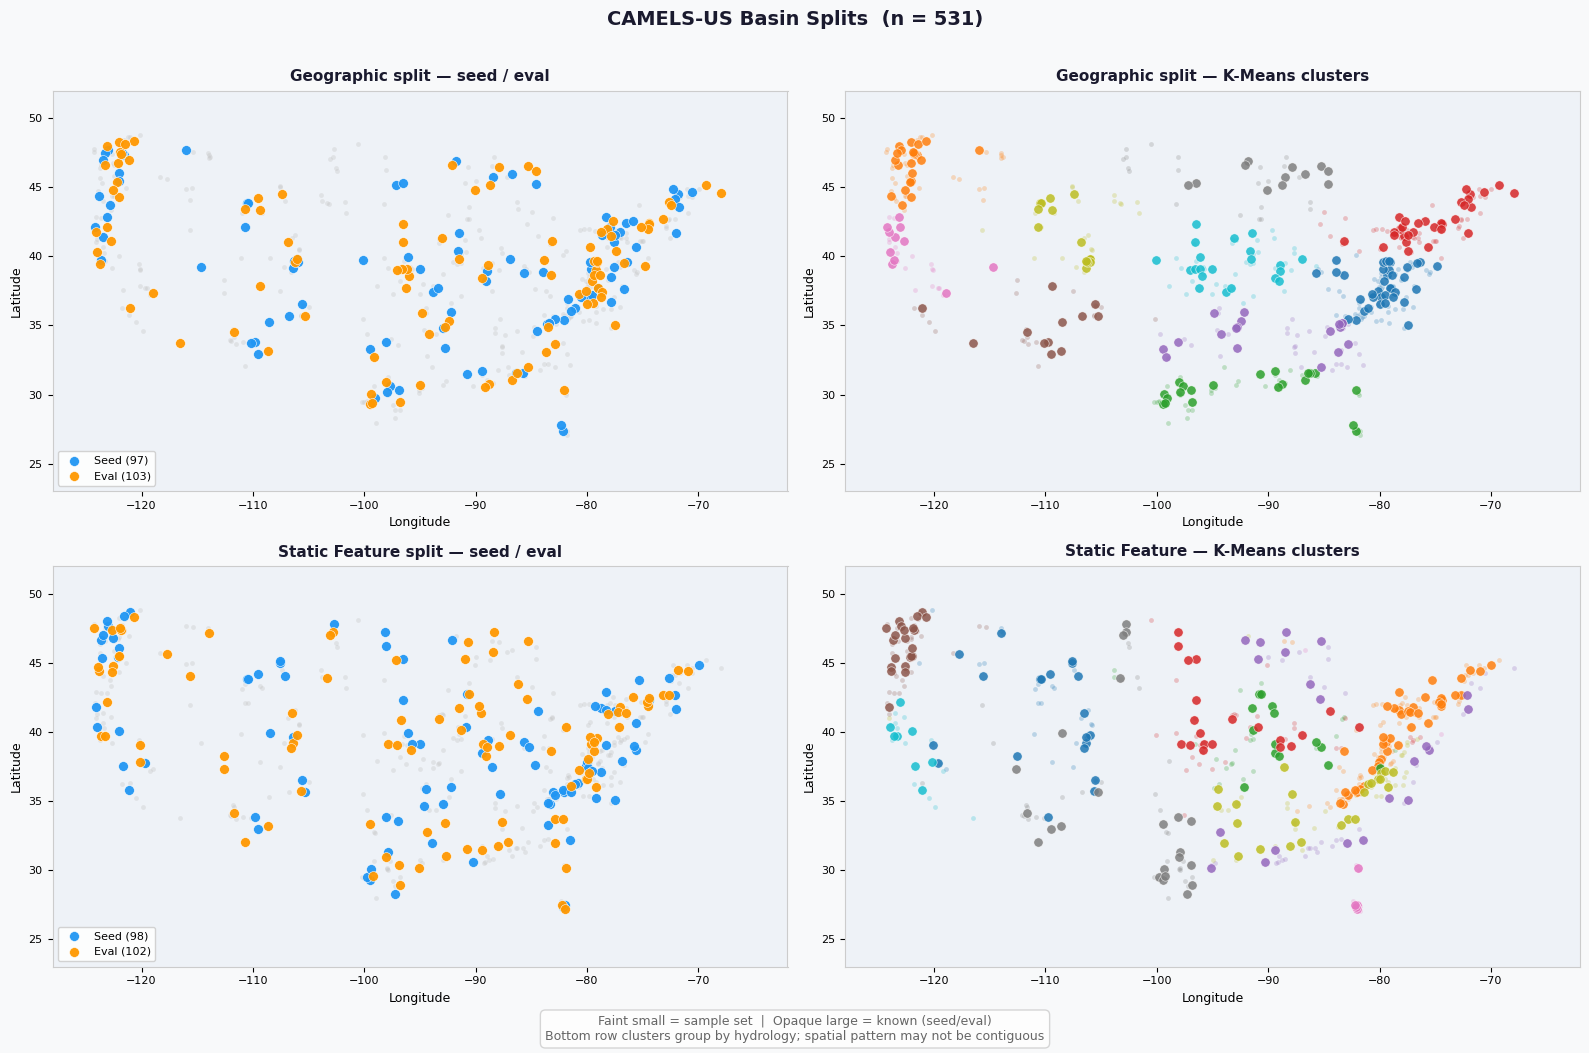

In [18]:
COLORS = {"seed": "#2196F3", "eval": "#FF9800", "pool": "#BDBDBD"}

def draw_split(ax, seed_idx, eval_idx, pool_idx, clusters, title, show_clusters=True):
    id_to_pos = {i: bid for i, bid in enumerate(basin_list)}
    seed_pos = np.array([id_to_pos[b] for b in seed_idx])
    eval_pos = np.array([id_to_pos[b] for b in eval_idx])
    pool_pos = np.array([id_to_pos[b] for b in pool_idx])
    ax.set_facecolor("#EEF2F7")

    lats, lons = lat_long[:, 0], lat_long[:, 1]
    if show_clusters:
        cmap = plt.colormaps.get_cmap("tab10")
        for c in np.unique(clusters):
            members = np.arange(531)[clusters == c]
            in_pool = np.isin(members, pool_idx)
            ax.scatter(lons[members[in_pool]],  lats[members[in_pool]],
                        s=12, color=cmap(c % 10), alpha=0.25, linewidths=0, zorder=2)
            ax.scatter(lons[members[~in_pool]], lats[members[~in_pool]],
                        s=45, color=cmap(c % 10), alpha=0.85,
                        linewidths=0.4, edgecolors="white", zorder=4)
    else:
        ax.scatter(lons[pool_idx], lats[pool_idx],
                    s=12, c=COLORS["pool"], alpha=0.3, linewidths=0, zorder=2)
        ax.scatter(lons[seed_idx], lats[seed_idx],
                    s=50, c=COLORS["seed"], alpha=0.95,
                    linewidths=0.4, edgecolors="white",
                    label=f"Seed ({len(seed_idx)})", zorder=4)
        ax.scatter(lons[eval_idx], lats[eval_idx],
                    s=50, c=COLORS["eval"], alpha=0.95,
                    linewidths=0.4, edgecolors="white",
                    label=f"Eval ({len(eval_idx)})", zorder=4)
        ax.legend(loc="lower left", fontsize=8, framealpha=0.85, edgecolor="#CCCCCC")

    ax.set_title(title, fontsize=11, fontweight="bold", pad=7, color="#1A1A2E")
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude",  fontsize=9)
    ax.set_xlim(-128, -62); ax.set_ylim(23, 52)
    ax.tick_params(labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor("#CCCCCC")

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor="#F8F9FA")
fig.suptitle("CAMELS-US Basin Splits  (n = 531)",
                fontsize=14, fontweight="bold", y=1.01, color="#1A1A2E")

draw_split(axes[0, 0], geo_seed, geo_eval, geo_pool, geo_clusters,
            "Geographic split — seed / eval", show_clusters=False)
draw_split(axes[0, 1], geo_seed, geo_eval, geo_pool, geo_clusters,
            "Geographic split — K-Means clusters", show_clusters=True)
draw_split(axes[1, 0], hyd_seed, hyd_eval, hyd_pool, hyd_clusters,
            "Static Feature split — seed / eval", show_clusters=False)
draw_split(axes[1, 1], hyd_seed, hyd_eval, hyd_pool, hyd_clusters,
            "Static Feature — K-Means clusters", show_clusters=True)

note = "Faint small = sample set  |  Opaque large = known (seed/eval)\nBottom row clusters group by hydrology; spatial pattern may not be contiguous"
fig.text(0.5, -0.02, note, ha="center", fontsize=9, color="#666666",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", alpha=0.8))

plt.tight_layout()

## Streamflow NaN Analysis

CAMELS-US has missing gauge records for some basins. We profile NaN values in the **training split** (Oct 1980 – Sep 1990) to understand which basins are affected and how severely.

In [9]:
# --- NaN analysis across all three temporal splits ---
for split_name in ['train', 'valid', 'test']:
    arr = np.load(f"{path}/strided_{split_name}.npz")['data']  # (531, W, 365, 33)
    sf = arr[:, :, :, 32]  # streamflow only
    nan_count = np.isnan(sf).sum()
    basins_affected = (np.isnan(sf).any(axis=(1, 2))).sum()
    print(f"{split_name:6s}: shape={arr.shape}  "
          f"NaN SF values={nan_count:>7,}  "
          f"basins affected={basins_affected}/531")

print()


train : shape=(531, 19, 365, 33)  NaN SF values=182,689  basins affected=55/531
valid : shape=(531, 9, 365, 33)  NaN SF values=      0  basins affected=0/531
test  : shape=(531, 19, 365, 33)  NaN SF values=      0  basins affected=0/531



In [10]:
# --- Per-basin NaN breakdown for the training split ---
train_arr = np.load(f"{path}/strided_train.npz")['data']  # (531, 19, 365, 33)
sf_train = train_arr[:, :, :, 32]                         # (531, 19, 365)
nan_mask = np.isnan(sf_train)

nan_basins = np.where(nan_mask.any(axis=(1, 2)))[0]
rows = []
for b in nan_basins:
    n_nan = nan_mask[b].sum()
    total = sf_train[b].size
    win_with_nan = nan_mask[b].any(axis=1).sum()
    last8_nan = nan_mask[b, :, -8:].sum()
    rows.append({
        'gauge_id': basin_list[b],
        'nan_timesteps': n_nan,
        'total_timesteps': total,
        'pct_nan': round(100 * n_nan / total, 1),
        'windows_with_nan': f"{win_with_nan}/19",
        'nan_in_last8': last8_nan,
    })

df_nan = pd.DataFrame(rows).sort_values('pct_nan', ascending=False).reset_index(drop=True)
print(f"Basins with NaN SF in training split: {len(df_nan)} / 531")
print()
print(df_nan.to_string(index=False))


NameError: name 'basin_list' is not defined

In [ ]:
# --- Map of NaN basins, coloured by % missing ---
fig, ax = plt.subplots(1, 1, figsize=(14, 6), facecolor='#F8F9FA')
ax.set_facecolor('#EEF2F7')

lats, lons = lat_long[:, 0], lat_long[:, 1]

# All basins in grey
ax.scatter(lons, lats, s=10, c='#BDBDBD', alpha=0.4, linewidths=0, zorder=2)

# NaN basins coloured by % missing
nan_pct = np.array([df_nan.loc[df_nan['gauge_id'] == basin_list[b], 'pct_nan'].values[0]
                    if basin_list[b] in df_nan['gauge_id'].values else 0
                    for b in nan_basins])
sc = ax.scatter(lons[nan_basins], lats[nan_basins],
                s=60, c=nan_pct, cmap='Reds', vmin=0, vmax=100,
                linewidths=0.4, edgecolors='#333333', zorder=4)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('% NaN streamflow (train split)', fontsize=9)

ax.set_title('Basins with missing streamflow in training split (1980–1990)', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_xlim(-128, -62); ax.set_ylim(23, 52)
for sp in ax.spines.values(): sp.set_edgecolor('#CCCCCC')
plt.tight_layout()
